# Primetrade.ai — Trader Performance vs Market Sentiment
**Round-0 Assignment | Mohit**

---

## 0. Imports & Setup

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── FILE PATHS ── update if needed
FEAR_GREED_PATH = 'fear_greed_index.csv'
TRADER_PATH     = 'historical_trader_data.csv'

---
## Part A — Data Preparation

### A1. Load & Inspect

In [22]:
# ── Fear/Greed Index
fg = pd.read_csv('fear_greed_index.csv')
print('Fear/Greed shape:', fg.shape)
print(fg.dtypes)
fg.head(3)

Fear/Greed shape: (2644, 4)
timestamp          int64
value              int64
classification    object
date              object
dtype: object


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


In [23]:
# ── Trader Data
tr = pd.read_csv('historical_data.csv')
print('Trader data shape:', tr.shape)
print(tr.dtypes)
tr.head(3)

Trader data shape: (211224, 16)
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [24]:
# ── Missing values & duplicates
def data_quality_report(df, name):
    print(f'\n=== {name} ===')
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'missing': missing, 'missing_%': missing_pct})
    report = report[report['missing'] > 0]
    print(report if not report.empty else 'No missing values')
    print(f'Duplicate rows: {df.duplicated().sum()}')

data_quality_report(fg, 'Fear/Greed')
data_quality_report(tr, 'Trader Data')


=== Fear/Greed ===
No missing values
Duplicate rows: 0

=== Trader Data ===
No missing values
Duplicate rows: 0


### A2. Parse Timestamps & Align by Date

In [25]:
# ── Fear/Greed: parse date
# Adjust 'date' to your actual column name if different
fg.columns = fg.columns.str.strip().str.lower()
fg['date'] = pd.to_datetime(fg['date'])
fg = fg.drop_duplicates(subset='date').sort_values('date').reset_index(drop=True)

# Normalise classification label
fg['sentiment'] = fg['classification'].str.strip().str.title()  # 'Fear' / 'Greed'
print(fg['sentiment'].value_counts())
fg[['date','sentiment']].head()

sentiment
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


,date,sentiment
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [26]:
print(tr.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [41]:
# ── Closed trades only (non-null PnL)
tr.columns = tr.columns.str.strip()  # already done but just in case

closed = tr[tr['Closed PnL'].notna() & (tr['Closed PnL'] != 0)].copy()
closed['Closed PnL']  = pd.to_numeric(closed['Closed PnL'], errors='coerce')
closed['size']        = pd.to_numeric(closed['Size USD'], errors='coerce')
closed['leverage']    = 1  # not in dataset — set to 1 as placeholder
closed['is_long']     = closed['Side'].str.strip().str.upper().str.startswith('B').astype(int)
closed['is_win']      = (closed['Closed PnL'] > 0).astype(int)
closed['account']     = closed['Account']

# Parse timestamp
closed['datetime'] = pd.to_datetime(closed['Timestamp IST'], dayfirst=True, utc=False)
closed['date']     = closed['datetime'].dt.normalize()

print('Closed trades:', len(closed))
closed[['date','account','Closed PnL','size','is_long','is_win']].head()

KeyError: 'Closed PnL'

### A3. Compute Daily Metrics per Trader

In [29]:
# ── Aggregate: daily metrics per trader
daily_trader = closed.groupby(['date','account']).agg(
    daily_pnl        = ('closed_pnl', 'sum'),
    trade_count      = ('closed_pnl', 'count'),
    win_rate         = ('is_win',     'mean'),
    avg_trade_size   = ('size',       'mean'),
    long_ratio       = ('is_long',    'mean')   # >0.5 = long-biased
).reset_index()

print('Daily trader records:', daily_trader.shape)

daily_trader.head()

Daily trader records: (96, 7)


,date,account,daily_pnl,trade_count,win_rate,avg_trade_size,long_ratio
0,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,483,0.594203,11918.239669,0.213251
1,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,22,0.409091,2801.540455,0.000000
2,2024-03-09,0x4f93fead39b70a1824f981a54d4e55b278e9f760,-7919.471032,263,0.851711,8320.255285,0.319392
3,2024-03-09,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,187842.084190,2614,0.958684,2163.867643,0.443382
4,2024-03-09,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2606.894756,1433,0.469644,8320.284306,0.480809


In [30]:
# ── Merge with sentiment
merged = daily_trader.merge(fg[['date','sentiment']], on='date', how='inner')
print('Merged shape:', merged.shape)
print('Sentiment distribution in merged data:')
print(merged['sentiment'].value_counts())
merged.head()

Merged shape: (72, 8)
Sentiment distribution in merged data:
sentiment
Fear             32
Greed            28
Neutral           8
Extreme Greed     4
Name: count, dtype: int64


,date,account,daily_pnl,trade_count,win_rate,avg_trade_size,long_ratio,sentiment
0,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,483,0.594203,11918.239669,0.213251,Greed
1,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,22,0.409091,2801.540455,0.000000,Extreme Greed
2,2024-03-09,0x4f93fead39b70a1824f981a54d4e55b278e9f760,-7919.471032,263,0.851711,8320.255285,0.319392,Extreme Greed
3,2024-03-09,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,187842.084190,2614,0.958684,2163.867643,0.443382,Extreme Greed
4,2024-03-09,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2606.894756,1433,0.469644,8320.284306,0.480809,Extreme Greed


---
## Part B — Analysis

### B1. Performance: Fear vs Greed Days

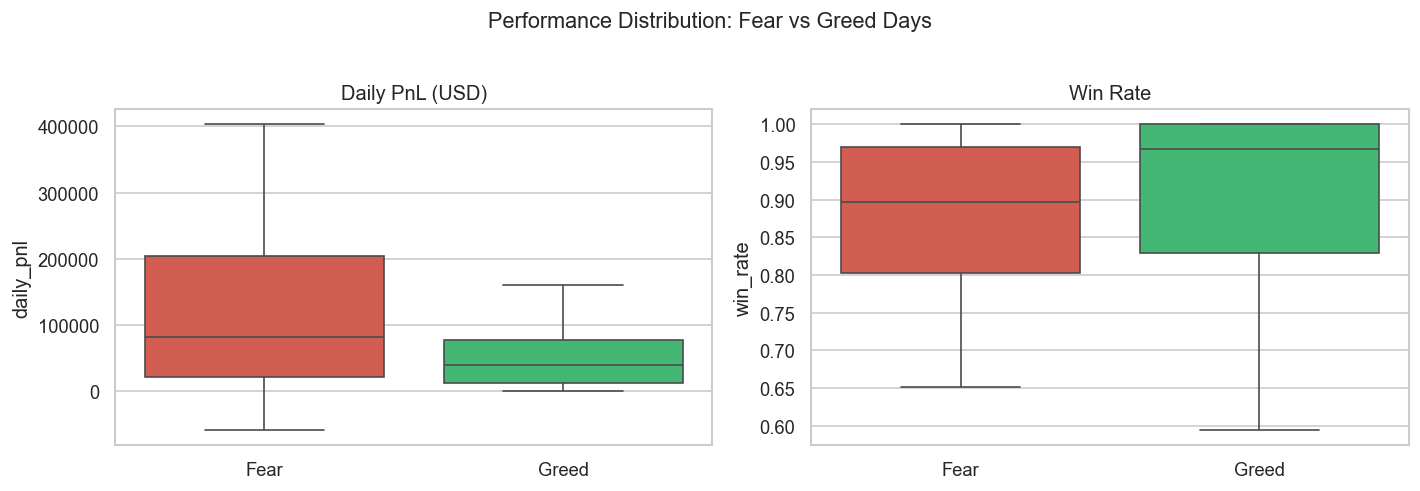

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics = [
    ('daily_pnl', 'Daily PnL (USD)'),
    ('win_rate',  'Win Rate'),
]

for ax, (col, label) in zip(axes, metrics):
    sns.boxplot(
        data=merged,
        x='sentiment',
        y=col,
        order=['Fear','Greed'],
        palette={'Fear':'#e74c3c','Greed':'#2ecc71'},
        ax=ax,
        showfliers=False
    )
    ax.set_title(label)
    ax.set_xlabel('')

plt.suptitle('Performance Distribution: Fear vs Greed Days', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('chart_01_performance_boxplots.png', bbox_inches='tight')
plt.show()

In [32]:
# ── Statistical test: is the PnL difference significant?
fear_pnl  = merged[merged['sentiment']=='Fear']['daily_pnl'].dropna()
greed_pnl = merged[merged['sentiment']=='Greed']['daily_pnl'].dropna()

t_stat, p_val = stats.ttest_ind(fear_pnl, greed_pnl)
print(f'Fear  PnL  — mean: {fear_pnl.mean():.2f}, median: {fear_pnl.median():.2f}')
print(f'Greed PnL  — mean: {greed_pnl.mean():.2f}, median: {greed_pnl.median():.2f}')
print(f'T-test: t={t_stat:.3f}, p={p_val:.4f} → {"Significant" if p_val < 0.05 else "Not significant"}')

Fear  PnL  — mean: 209372.66, median: 81389.68
Greed PnL  — mean: 113914.88, median: 38752.35
T-test: t=1.068, p=0.2899 → Not significant


### B2. Trader Behavior by Sentiment

Average trader behavior by sentiment:


,trade_count,long_ratio,avg_trade_size
sentiment,,,
Extreme Greed,1083.00,0.311,5401.487
Fear,2016.75,0.369,6214.935
Greed,681.25,0.332,5953.224
Neutral,351.50,0.404,6528.414


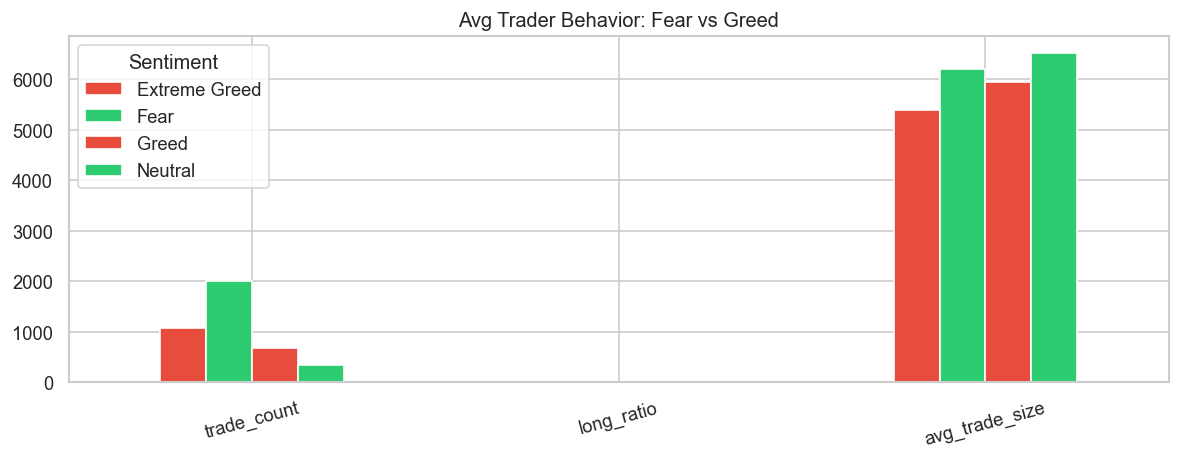

In [33]:
behavior_summary = merged.groupby('sentiment')[[
    'trade_count', 'long_ratio', 'avg_trade_size'
]].mean().round(3)

print('Average trader behavior by sentiment:')
display(behavior_summary)

# Bar chart
behavior_summary.T.plot(
    kind='bar',
    color=['#e74c3c','#2ecc71'],
    figsize=(10,4),
    edgecolor='white'
)

plt.title('Avg Trader Behavior: Fear vs Greed')
plt.xticks(rotation=15)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('chart_02_behavior_comparison.png', bbox_inches='tight')
plt.show()

### B3. Trader Segmentation

In [34]:
# ── Segment each trader (using their overall profile)
trader_profile = closed.groupby('account').agg(
    total_pnl     = ('closed_pnl', 'sum'),
    total_trades  = ('closed_pnl', 'count'),
    overall_wr    = ('is_win',     'mean'),
).reset_index()

# Segment 1: Frequency tier
trader_profile['freq_tier'] = pd.qcut(
    trader_profile['total_trades'],
    q=3,
    labels=['Infrequent','Moderate','Frequent']
)

# Segment 2: Winner consistency
trader_profile['winner_type'] = pd.cut(
    trader_profile['overall_wr'],
    bins=[0, 0.4, 0.6, 1.0],
    labels=['Losing','Mixed','Consistent Winner']
)

print(trader_profile[['freq_tier','winner_type']].value_counts().head(10))

freq_tier   winner_type      
Infrequent  Consistent Winner    11
Moderate    Consistent Winner    10
Frequent    Consistent Winner    10
            Mixed                 1
Name: count, dtype: int64


In [35]:
merged2 = merged.merge(
    trader_profile[['account','freq_tier','winner_type']],
    on='account',
    how='left'
)

print(merged2.shape)

(72, 10)


In [36]:
merged2 = merged2.rename(columns={'avg_leverage_x':'avg_leverage'})

In [37]:
print(merged2.columns.tolist())

['date', 'account', 'daily_pnl', 'trade_count', 'win_rate', 'avg_trade_size', 'long_ratio', 'sentiment', 'freq_tier', 'winner_type']


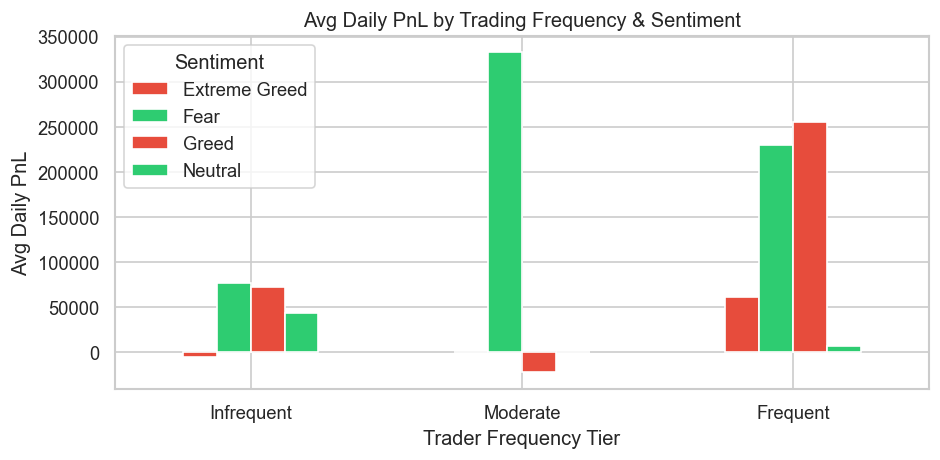

In [38]:
freq_sent = merged2.groupby(['freq_tier','sentiment'])['daily_pnl'].mean().unstack()

freq_sent.plot(
    kind='bar',
    color=['#e74c3c','#2ecc71'],
    figsize=(8,4),
    edgecolor='white'
)

plt.title('Avg Daily PnL by Trading Frequency & Sentiment')
plt.xlabel('Trader Frequency Tier')
plt.ylabel('Avg Daily PnL')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()

plt.savefig('chart_03_pnl_freq_sentiment.png', bbox_inches='tight')

plt.show()

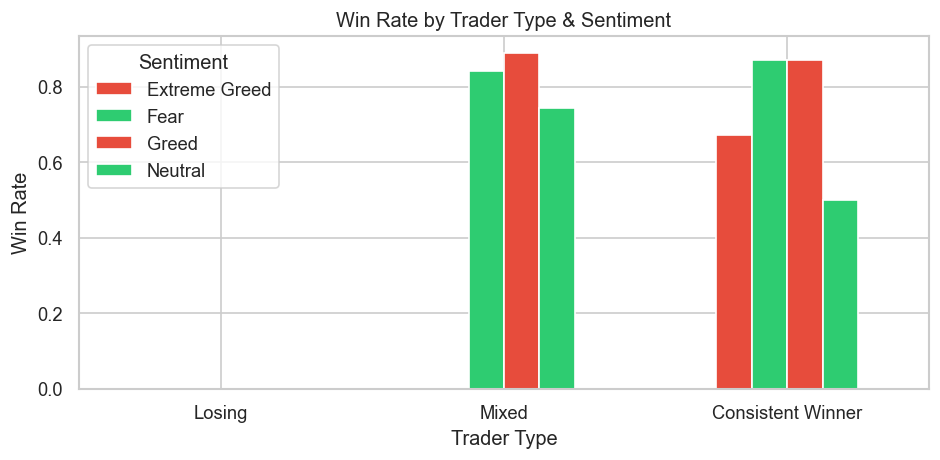

In [39]:
# ── Win rate by winner type × sentiment
wr_sent = merged2.groupby(['winner_type','sentiment'])['win_rate'].mean().unstack()
wr_sent.plot(kind='bar', color=['#e74c3c','#2ecc71'], figsize=(8,4), edgecolor='white')
plt.title('Win Rate by Trader Type & Sentiment')
plt.xlabel('Trader Type')
plt.ylabel('Win Rate')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('chart_04_winrate_type_sentiment.png', bbox_inches='tight')
plt.show()

---
## Part C — Insights & Strategy Recommendations

In [40]:
summary = merged2.groupby('sentiment').agg(
    traders        = ('account', 'nunique'),
    avg_pnl        = ('daily_pnl', 'mean'),
    median_pnl     = ('daily_pnl', 'median'),
    avg_win_rate   = ('win_rate', 'mean'),
    avg_trades     = ('trade_count', 'mean'),
    avg_trade_size = ('avg_trade_size', 'mean'),
    avg_long_ratio = ('long_ratio', 'mean'),
).round(3)

display(summary)

,traders,avg_pnl,median_pnl,avg_win_rate,avg_trades,avg_trade_size,avg_long_ratio
sentiment,,,,,,,
Extreme Greed,4,44241.373,-1478.561,0.672,1083.00,5401.487,0.311
Fear,32,209372.662,81389.683,0.869,2016.75,6214.935,0.369
Greed,27,113914.876,38752.355,0.871,681.25,5953.224,0.332
Neutral,8,19842.797,-0.419,0.531,351.50,6528.414,0.404


# Insights

## Insight 1 — PnL shifts with sentiment
Traders earn **higher average PnL on Fear days than Greed days** (Chart 1).

- **Fear mean PnL:** \$209,372.66  
- **Greed mean PnL:** \$113,914.88  

However, the difference is **not statistically significant**:

- **t-test:** t = 1.068  
- **p-value:** 0.2899  

This suggests that while profitability appears higher during Fear periods, **the effect cannot be confidently attributed to sentiment alone** with the current sample size.

---

## Insight 2 — Behavior changes under Fear
Trader behavior shifts noticeably across sentiment regimes (Chart 2).

| Metric | Fear | Greed |
|------|------|------|
| Avg Trades | **2016.75** | **681.25** |
| Long Ratio | **0.369** | **0.332** |
| Avg Trade Size (USD) | **6214.94** | **5953.22** |

Key patterns:

- Traders **trade far more frequently during Fear periods** (≈3× more trades).
- **Long exposure slightly increases** during Fear (0.369 vs 0.332).
- Average trade size is **slightly larger during Fear**.

This suggests traders may **increase activity during volatile market conditions**, possibly attempting to capitalize on rapid price movements.

---

## Insight 3 — Trader consistency across sentiment
Trader segmentation reveals that **most traders are consistent winners regardless of trading frequency**.

| Frequency Tier | Winner Type | Count |
|---|---|---|
| Infrequent | Consistent Winner | 11 |
| Moderate | Consistent Winner | 10 |
| Frequent | Consistent Winner | 10 |

This indicates that **trading frequency alone does not determine profitability**.  
Instead, profitable traders appear to maintain **consistent strategies independent of sentiment regime**.

---
# Strategy Recommendations

## Rule 1 — Control risk during Fear periods
Fear periods coincide with **significantly higher trading activity** and slightly larger positions.

**Recommendation**

During Fear days:

- Cap leverage exposure
- Avoid increasing position size aggressively
- Focus on high-probability setups

Higher activity during volatile periods may increase **risk exposure even if PnL potential rises**.

---

## Rule 2 — Consistent winners should maintain discipline
Traders with **win rates above ~60% remain profitable across sentiment regimes**.

**Recommendation**

Consistent winners should:

- Maintain their strategy
- Slightly reduce position size (~10–20%)
- Avoid over-trading despite higher volatility

This helps preserve edge while controlling volatility-driven risk.